# Fine-tuning một mô hình reranker `namdp-ptit/ViRanker` cho truy xuất văn bản pháp luật tiếng Việt

## 0. Mục tiêu bài toán

Notebook này fine-tune mô hình reranker `namdp-ptit/ViRanker` cho bài toán truy xuất văn bản pháp luật tiếng Việt. Với mỗi câu hỏi pháp luật `query`, hệ thống tạo một nhóm ứng viên gồm `1 positive passage` và nhiều `negative passages`; mô hình học cách chấm điểm để passage đúng được xếp cao nhất.

Trong pipeline RAG, reranker nằm sau bước truy xuất ban đầu:

```text
User query
    ->
Retriever / BM25 / FAISS lấy top-k documents
    ->
Reranker chấm điểm từng cặp (query, passage)
    ->
Sắp xếp lại candidates theo điểm reranker
    ->
Đưa top passages vào LLM hoặc trả kết quả cho người dùng
```

Mục tiêu thực nghiệm trong notebook:

1. Chuẩn hóa và gộp dữ liệu legal QA tiếng Việt từ 3 nguồn, sau deduplicate còn `37,781` cặp query-passage hợp lệ.
2. Fine-tune `namdp-ptit/ViRanker` bằng groupwise cross-entropy với TF-IDF hard negatives.
3. So sánh model sau fine-tune với chính `namdp-ptit/ViRanker` ở trạng thái pretrained trên cùng test set và cùng bộ hard negatives.
4. Xuất model, training logs, bảng metric, confusion matrix và các ví dụ lỗi để phục vụ báo cáo.


## 1. Cài đặt thư viện


In [1]:
!pip install -U torch transformers datasets accelerate scikit-learn tqdm pandas sentencepiece protobuf matplotlib

In [2]:
# Fix lỗi torchvision trước khi import transformers.
# Với bài toán NLP reranking, notebook không cần torchvision.
import os
import sys
import subprocess

os.environ["TRANSFORMERS_NO_TORCHVISION"] = "1"

subprocess.run(
    [sys.executable, "-m", "pip", "uninstall", "-y", "torchvision"],
    check=False,
)

import gc
import json
import math
import random
import inspect
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset

from datasets import load_dataset
from tqdm.auto import tqdm
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)

print("Đã cấu hình môi trường và import thư viện.")


Đã cấu hình môi trường và import thư viện.


## 2. Thiết lập thư mục làm việc trên Colab local

Notebook lưu output chính trong local runtime `/content` thay vì ghi trực tiếp vào Google Drive. Cách này tránh làm đầy Drive trong lúc training vì checkpoint và file zip có thể rất lớn. Sau khi train xong, chỉ copy các artifact cần giữ lâu dài sang Drive.


In [3]:
import os

# Do not mount/cd into Google Drive, so outputs do not use Drive storage.
# Everything generated by this notebook is saved in Colab local runtime /content.
PROJECT_DIR = "/content"
os.chdir(PROJECT_DIR)

print("Project dir:", PROJECT_DIR)
print("Current working directory:", os.getcwd())


Project dir: /content
Current working directory: /content


## 3. Import thư viện và cấu hình thí nghiệm

Dữ liệu được chia theo tỷ lệ **70/15/15** cho Train/Validation/Test. Trong lần chạy hiện tại, sau deduplicate có `37,781` mẫu, được chia thành `26,446` mẫu train, `5,667` mẫu validation và `5,668` mẫu test.

Cách chia dùng **passage group split**: các sample có cùng positive passage được đưa về cùng một tập để hạn chế rò rỉ passage giữa train/validation/test.

Reranker tiêu tốn VRAM theo số cặp `(query, passage)`, nên batch size được tính theo **số query-group**. Với cấu hình hiện tại, mỗi group train gồm `1 positive + 3 negatives`; batch size theo group là `2`, gradient accumulation là `8`.


In [4]:
# ===== Cấu hình chính =====
MODEL_NAME = "namdp-ptit/ViRanker"
OUTPUT_PATH = "/content/vietlaw-viranker-finetuned"

SEED = 42

# Chia dữ liệu theo yêu cầu báo cáo: Train / Validation / Test.
TRAIN_SIZE = 0.70
VAL_SIZE = 0.15
TEST_SIZE = 0.15
assert abs(TRAIN_SIZE + VAL_SIZE + TEST_SIZE - 1.0) < 1e-9

# ViRanker hỗ trợ ngữ cảnh dài, nhưng training dài rất tốn VRAM.
MAX_LENGTH = 512

# Mỗi query trong train có 1 positive + TRAIN_NEGATIVES_PER_QUERY negatives.
TRAIN_NEGATIVES_PER_QUERY = 3

# Batch size tính theo số query-group, không phải số cặp.
# Số forward pairs thực tế = PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY)
PER_DEVICE_TRAIN_BATCH_SIZE = 2
GRADIENT_ACCUMULATION_STEPS = 8

EPOCHS = 2
LEARNING_RATE = 2e-5
WARMUP_RATIO = 0.10
WEIGHT_DECAY = 0.01

# Sinh negative: "tfidf" tạo semi-hard/hard negatives; "random" nhanh hơn nhưng dễ hơn.
NEGATIVE_STRATEGY = "tfidf"   # "tfidf" hoặc "random"
TFIDF_TOP_K_POOL = 50

# Validation/test cũng dùng hard negatives thay vì random negatives.
# Validation group dùng số negative bằng train để tính eval_loss/eval_mrr trong Trainer.
VAL_NEGATIVES_PER_QUERY = TRAIN_NEGATIVES_PER_QUERY

# Evaluation ranking cuối: 1 positive + EVAL_NEGATIVES_PER_QUERY hard negatives.
EVAL_NEGATIVES_PER_QUERY = 31
EVAL_TFIDF_TOP_K_POOL = 100

# Đánh giá baseline là cùng model pretrained trước khi fine-tune.
RUN_BASELINE_EVAL = True

# Log train và validation đồng bộ theo step.
# Ví dụ EPOCHS=2 và LOG_EVALS_PER_EPOCH=4 thì có khoảng 8 điểm val trên learning curve.
LOG_EVALS_PER_EPOCH = 4

# Early stopping dựa trên validation MRR.
EARLY_STOPPING_PATIENCE = 2
EARLY_STOPPING_THRESHOLD = 0.0005

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Không giới hạn số lượng mẫu ở các tập.
MAX_TRAIN_QUERIES = None
MAX_VAL_QUERIES = None
MAX_TEST_QUERIES = None

# Không giới hạn số lượng query dùng để đánh giá validation/test.
MAX_VALIDATION_QUERIES = None

print("Thiết bị:", DEVICE)
print("Tỷ lệ chia dữ liệu:", {"train": TRAIN_SIZE, "validation": VAL_SIZE, "test": TEST_SIZE})
print("Validation/test negatives:", "TF-IDF hard negatives")


Thiết bị: cuda
Tỷ lệ chia dữ liệu: {'train': 0.7, 'validation': 0.15, 'test': 0.15}
Validation/test negatives: TF-IDF hard negatives


In [5]:
# Cố định thêm một số nguồn ngẫu nhiên để kết quả dễ tái lập hơn.
os.environ["PYTHONHASHSEED"] = str(SEED)

# Cấu hình deterministic có thể làm chậm nhẹ, nhưng giúp báo cáo ổn định hơn.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print("Đã cố định random seed:", SEED)


Đã cố định random seed: 42


## 4. Tải và chuẩn hóa dữ liệu

Notebook tải dữ liệu từ 3 nguồn Hugging Face:

- `adamwhite625/vietnam-legal-qa`: thu được `4,837` cặp.
- `huyydangg/LEGAL-EVAL-Dataset`: sau xử lý còn `3,806` cặp trong bảng phân bố cuối.
- `thangvip/vietnamese-legal-qa`: nguồn lớn nhất, sau deduplicate còn `29,138` cặp.

Tổng cộng sau chuẩn hóa và loại trùng còn `37,781` cặp query-passage hợp lệ.


In [6]:
def _clean_text(x) -> str:
    if x is None:
        return ""
    if isinstance(x, (list, tuple)):
        x = " ".join([str(i) for i in x])
    return str(x).strip()


def _parse_generated_qa_pairs(value):
    """Dataset thangvip thường là list[dict], nhưng hàm này cũng xử lý trường hợp bị lưu dạng string."""
    if isinstance(value, list):
        return value
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        try:
            return json.loads(value)
        except Exception:
            pass
        try:
            import ast
            return ast.literal_eval(value)
        except Exception:
            return []
    return []


def load_adamwhite625():
    print("Đang tải dataset: adamwhite625/vietnam-legal-qa...")
    try:
        ds = load_dataset("adamwhite625/vietnam-legal-qa", split="train")
        standardized_data = []
        for row in ds:
            q = _clean_text(row.get("question", ""))
            a = _clean_text(row.get("law_content", ""))
            if q and a and len(a) > 50:
                standardized_data.append({"query": q, "pos": a, "source": "adamwhite625/vietnam-legal-qa"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải adamwhite625/vietnam-legal-qa: {e}")
        return []


def load_huyydangg():
    print("Đang tải dataset: huyydangg/LEGAL-EVAL-Dataset...")
    try:
        ds = load_dataset("huyydangg/LEGAL-EVAL-Dataset", split="test")
        standardized_data = []
        for row in ds:
            q = _clean_text(row.get("anchor", ""))
            a = _clean_text(row.get("positive", ""))
            if q and a and len(a) > 50:
                standardized_data.append({"query": q, "pos": a, "source": "huyydangg/LEGAL-EVAL-Dataset"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải huyydangg/LEGAL-EVAL-Dataset: {e}")
        return []


def load_thangvip():
    print("Đang tải dataset: thangvip/vietnamese-legal-qa...")
    try:
        ds = load_dataset("thangvip/vietnamese-legal-qa", split="train")
        standardized_data = []
        for row in ds:
            qa_pairs = _parse_generated_qa_pairs(row.get("generated_qa_pairs", []))
            if not isinstance(qa_pairs, list):
                continue
            for pair in qa_pairs:
                if not isinstance(pair, dict):
                    continue
                q = _clean_text(pair.get("question", ""))
                a = _clean_text(pair.get("answer", ""))
                if q and a and len(a) > 50:
                    standardized_data.append({"query": q, "pos": a, "source": "thangvip/vietnamese-legal-qa"})
        print(f"-> Thu thập được {len(standardized_data)} cặp.")
        return standardized_data
    except Exception as e:
        print(f"Lỗi khi tải thangvip/vietnamese-legal-qa: {e}")
        return []


def deduplicate_pairs(data: List[Dict[str, str]]) -> List[Dict[str, str]]:
    seen = set()
    deduped = []
    for item in data:
        q = _clean_text(item.get("query"))
        p = _clean_text(item.get("pos"))
        key = (q, p)
        if q and p and key not in seen:
            seen.add(key)
            deduped.append({**item, "query": q, "pos": p})
    return deduped


In [7]:
data1 = load_adamwhite625()
data2 = load_huyydangg()
data3 = load_thangvip()

all_data = deduplicate_pairs(data1 + data2 + data3)

def normalize_text(text):
    return " ".join(str(text).strip().lower().split())

def split_by_passage_group(data, train_size=0.7, val_size=0.15, seed=42):
    """
    Chia dữ liệu theo nhóm passage.
    Tất cả sample có cùng positive passage sẽ nằm trong cùng một tập.
    Mục tiêu: giảm/loại bỏ passage overlap giữa Train/Validation/Test.
    """
    rng = random.Random(seed)

    passage_groups = {}
    for item in data:
        passage_key = normalize_text(item["pos"])
        passage_groups.setdefault(passage_key, []).append(item)

    groups = list(passage_groups.values())
    rng.shuffle(groups)

    n_total = len(data)
    targets = {
        "train": int(n_total * train_size),
        "val": int(n_total * val_size),
        "test": n_total - int(n_total * train_size) - int(n_total * val_size),
    }

    splits = {
        "train": [],
        "val": [],
        "test": [],
    }

    for group in groups:
        # Chọn tập đang thiếu dữ liệu nhiều nhất theo tỷ lệ target
        best_split = min(
            splits.keys(),
            key=lambda name: len(splits[name]) / max(targets[name], 1)
        )
        splits[best_split].extend(group)

    # Shuffle lại trong từng split để tránh dữ liệu bị gom theo passage
    for name in splits:
        rng.shuffle(splits[name])

    return splits["train"], splits["val"], splits["test"]

train_data, val_data, test_data = split_by_passage_group(
    all_data,
    train_size=TRAIN_SIZE,
    val_size=VAL_SIZE,
    seed=SEED
)

n_total = len(all_data)

if MAX_TRAIN_QUERIES is not None:
    train_data = train_data[:MAX_TRAIN_QUERIES]

if MAX_VAL_QUERIES is not None:
    val_data = val_data[:MAX_VAL_QUERIES]

if MAX_TEST_QUERIES is not None:
    test_data = test_data[:MAX_TEST_QUERIES]

eval_val_data = val_data[:MAX_VALIDATION_QUERIES] if MAX_VALIDATION_QUERIES is not None else val_data
eval_test_data = test_data[:MAX_TEST_QUERIES] if MAX_TEST_QUERIES is not None else test_data

print(f"Tổng số cặp Q&A hợp lệ sau deduplicate: {n_total}")
print(f"Số lượng Train: {len(train_data)}")
print(f"Số lượng Validation gốc: {len(val_data)}")
print(f"Số lượng Test gốc: {len(test_data)}")
print(f"Số lượng Validation dùng khi chạy nhanh: {len(eval_val_data)}")
print(f"Số lượng Test dùng khi chạy nhanh: {len(eval_test_data)}")

assert len(train_data) > 0 and len(val_data) > 0 and len(test_data) > 0, "Không có đủ dữ liệu để chia Train/Validation/Test."

split_summary = pd.DataFrame([
    {"Tập dữ liệu": "Train", "Số mẫu": len(train_data), "Tỷ lệ dự kiến": f"{TRAIN_SIZE:.0%}", "Vai trò": "Huấn luyện mô hình"},
    {"Tập dữ liệu": "Validation", "Số mẫu": len(val_data), "Tỷ lệ dự kiến": f"{VAL_SIZE:.0%}", "Vai trò": "Theo dõi learning curves và chọn checkpoint"},
    {"Tập dữ liệu": "Test", "Số mẫu": len(test_data), "Tỷ lệ dự kiến": f"{TEST_SIZE:.0%}", "Vai trò": "Đánh giá cuối cùng"},
])

print("Bảng 2. Thống kê số mẫu theo từng tập dữ liệu")
display(split_summary)

source_summary = pd.Series([x["source"] for x in all_data]).value_counts().reset_index()
source_summary.columns = ["Nguồn dữ liệu", "Số mẫu"]
print("Bảng 3. Phân bố mẫu theo nguồn dữ liệu")
display(source_summary)

Đang tải dataset: adamwhite625/vietnam-legal-qa...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/850 [00:00<?, ?B/s]

ready_to_import_dataset.json:   0%|          | 0.00/8.27M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4837 [00:00<?, ? examples/s]

...

Generating train split:   0%|          | 0/9715 [00:00<?, ? examples/s]

-> Thu thập được 29140 cặp.
Tổng số cặp Q&A hợp lệ sau deduplicate: 37781
Số lượng Train: 26446
Số lượng Validation gốc: 5667
Số lượng Test gốc: 5668
Số lượng Validation dùng khi chạy nhanh: 5667
Số lượng Test dùng khi chạy nhanh: 5668
Bảng 2. Thống kê số mẫu theo từng tập dữ liệu


,Tập dữ liệu,Số mẫu,Tỷ lệ dự kiến,Vai trò
0,Train,26446,70%,Huấn luyện mô hình
1,Validation,5667,15%,Theo dõi learning curves và chọn checkpoint
2,Test,5668,15%,Đánh giá cuối cùng


Bảng 3. Phân bố mẫu theo nguồn dữ liệu


,Nguồn dữ liệu,Số mẫu
0,thangvip/vietnamese-legal-qa,29138
1,adamwhite625/vietnam-legal-qa,4837
2,huyydangg/LEGAL-EVAL-Dataset,3806


In [9]:
# Tao cac set query/passage truoc khi kiem tra overlap.
train_queries = {normalize_text(x["query"]) for x in train_data}
val_queries = {normalize_text(x["query"]) for x in val_data}
test_queries = {normalize_text(x["query"]) for x in test_data}

train_passages = {normalize_text(x["pos"]) for x in train_data}
val_passages = {normalize_text(x["pos"]) for x in val_data}
test_passages = {normalize_text(x["pos"]) for x in test_data}

overlap_summary = pd.DataFrame([
    {"Loai overlap": "Train-Val query", "So luong": len(train_queries & val_queries)},
    {"Loai overlap": "Train-Test query", "So luong": len(train_queries & test_queries)},
    {"Loai overlap": "Val-Test query", "So luong": len(val_queries & test_queries)},
    {"Loai overlap": "Train-Val passage", "So luong": len(train_passages & val_passages)},
    {"Loai overlap": "Train-Test passage", "So luong": len(train_passages & test_passages)},
    {"Loai overlap": "Val-Test passage", "So luong": len(val_passages & test_passages)},
])

print("Bang kiem tra overlap giua cac tap du lieu")
display(overlap_summary)


Bang kiem tra overlap giua cac tap du lieu


,Loai overlap,So luong
0,Train-Val query,6
1,Train-Test query,6
2,Val-Test query,1
3,Train-Val passage,0
4,Train-Test passage,0
5,Val-Test passage,0


### 4.1. Tiền xử lý dữ liệu

Các bước tiền xử lý đã áp dụng:

1. **Chuẩn hóa schema**: gom nhiều định dạng dữ liệu khác nhau về hai trường chính `query` và `pos`.
2. **Làm sạch chuỗi**: chuyển list/tuple sang chuỗi, strip khoảng trắng và bỏ mẫu quá ngắn hoặc thiếu nội dung.
3. **Parse QA dạng JSON/string**: áp dụng cho dataset có trường chứa nhiều cặp hỏi đáp trong một bản ghi.
4. **Deduplicate**: loại bỏ cặp `(query, pos)` trùng nhau, kết quả cuối là `37,781` mẫu.
5. **Chia tập theo positive passage**: hạn chế trường hợp cùng một passage xuất hiện ở nhiều split.
6. **Tokenization theo cặp**: tokenizer nhận đồng thời `(query, passage)`.
7. **Truncation**: giới hạn `MAX_LENGTH = 512`, nên passage dài có thể bị cắt ở phần cuối.
8. **Negative sampling**: dùng TF-IDF hard negatives để tạo các passage sai nhưng gần query về mặt từ vựng.

Không dùng paraphrase/tăng cường dữ liệu vì trong miền pháp luật, thay đổi câu chữ tự động có thể làm sai nghĩa pháp lý.


## 5. Lựa chọn mô hình và lý do

Notebook này huấn luyện một mô hình reranking chính: `namdp-ptit/ViRanker`.

**Bảng 4. Mô hình được huấn luyện và đánh giá trong notebook**

| Mô hình | Loại | Vai trò | Lý do chọn |
|---|---|---|---|
| `namdp-ptit/ViRanker` | Cross-encoder reranker cho tiếng Việt | Mô hình chính | Phù hợp với bài toán chấm điểm trực tiếp cặp `query` - `passage`; mô hình nhìn đồng thời cả câu hỏi và đoạn luật nên phù hợp cho bước reranking sau retriever. |

ViRanker được đánh giá ở hai trạng thái:

- **Baseline pretrained**: model gốc, chưa fine-tune trên tập legal QA của notebook.
- **Fine-tuned**: model sau khi huấn luyện trên tập train với TF-IDF hard negatives.

Hai trạng thái này được so sánh trên cùng test set gồm `5,668` query, mỗi query có `32` candidates (`1 positive + 31 negatives`).


## 5.1. Tạo hard negatives cho reranker

Notebook dùng TF-IDF để tạo **hard negatives** cho train, validation và test. Negative không được lấy ngẫu nhiên thuần túy; chúng là những passage có độ tương đồng từ vựng cao với query nhưng không phải positive passage.

Cấu hình thực nghiệm:

- Train/Validation group: `1 positive + 3 negatives`.
- Test ranking: `1 positive + 31 negatives`, tức `32` candidates/query.
- Negative strategy: `tfidf` với pool train `50` và pool eval `100`.

Cách này làm bài toán khó hơn và sát với thực tế hơn, vì reranker phải phân biệt các đoạn pháp luật có từ khóa gần nhau.


In [10]:
def random_negatives_for_index(
    idx: int,
    data: List[Dict[str, str]],
    num_negatives: int,
    rng: random.Random,
) -> List[str]:
    pos = data[idx]["pos"]
    n = len(data)
    negatives = []
    attempts = 0
    while len(negatives) < num_negatives and attempts < 500:
        j = rng.randrange(n)
        candidate = data[j]["pos"]
        if j != idx and candidate != pos and candidate not in negatives:
            negatives.append(candidate)
        attempts += 1

    # Fallback tuyến tính nếu random chưa đủ.
    if len(negatives) < num_negatives:
        for j, item in enumerate(data):
            candidate = item["pos"]
            if j != idx and candidate != pos and candidate not in negatives:
                negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break
    return negatives


def build_random_negatives(
    data: List[Dict[str, str]],
    num_negatives: int,
    seed: int = 42,
) -> List[List[str]]:
    rng = random.Random(seed)
    return [random_negatives_for_index(i, data, num_negatives, rng) for i in tqdm(range(len(data)), desc="Random negatives")]


def build_tfidf_negatives(
    data: List[Dict[str, str]],
    num_negatives: int,
    top_k_pool: int = 50,
    seed: int = 42,
    batch_size: int = 128,
    desc: str = "TF-IDF hard negatives",
) -> List[List[str]]:
    """Sinh hard negatives bằng TF-IDF.

    Với mỗi query, hàm lấy các passage có độ giống TF-IDF cao nhất nhưng không phải positive.
    Đây là negative sampling khó hơn random vì các passage sai thường có từ khóa gần với query.
    """
    rng = random.Random(seed)
    queries = [x["query"] for x in data]
    passages = [x["pos"] for x in data]
    n = len(data)

    if n <= 1:
        return [[] for _ in data]

    print(f"Đang fit TF-IDF trên {n} passages để tạo {desc}...")
    vectorizer = TfidfVectorizer(
        lowercase=True,
        max_features=100_000,
        ngram_range=(1, 2),
        min_df=2,
    )
    doc_matrix = vectorizer.fit_transform(passages)
    query_matrix = vectorizer.transform(queries)

    all_negatives = []
    k = min(top_k_pool + 1, n)

    for start in tqdm(range(0, n, batch_size), desc=desc):
        end = min(start + batch_size, n)
        sims = query_matrix[start:end].dot(doc_matrix.T).toarray()

        for local_i, scores in enumerate(sims):
            idx = start + local_i
            pos = passages[idx]

            # Lấy top-k ứng viên giống query nhất.
            if k < n:
                candidate_idx = np.argpartition(-scores, kth=k - 1)[:k]
            else:
                candidate_idx = np.arange(n)

            candidate_idx = candidate_idx[np.argsort(-scores[candidate_idx])]

            negatives = []
            for j in candidate_idx:
                candidate = passages[int(j)]
                if int(j) != idx and candidate != pos and candidate not in negatives:
                    negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break

            # Fallback random nếu top-k chưa đủ negative.
            if len(negatives) < num_negatives:
                extra = random_negatives_for_index(idx, data, num_negatives - len(negatives), rng)
                for item in extra:
                    if item not in negatives:
                        negatives.append(item)
                    if len(negatives) == num_negatives:
                        break

            all_negatives.append(negatives)

    return all_negatives


# 1) Train negatives.
if NEGATIVE_STRATEGY == "tfidf":
    train_negatives = build_tfidf_negatives(
        train_data,
        num_negatives=TRAIN_NEGATIVES_PER_QUERY,
        top_k_pool=TFIDF_TOP_K_POOL,
        seed=SEED,
        desc="Train TF-IDF hard negatives",
    )
elif NEGATIVE_STRATEGY == "random":
    train_negatives = build_random_negatives(
        train_data,
        num_negatives=TRAIN_NEGATIVES_PER_QUERY,
        seed=SEED,
    )
else:
    raise ValueError("NEGATIVE_STRATEGY phải là 'tfidf' hoặc 'random'.")

# 2) Validation negatives cho Trainer: dùng hard negatives để eval_loss/eval_mrr khó hơn random.
val_group_negatives = build_tfidf_negatives(
    eval_val_data,
    num_negatives=VAL_NEGATIVES_PER_QUERY,
    top_k_pool=TFIDF_TOP_K_POOL,
    seed=SEED + 13,
    desc="Validation group TF-IDF hard negatives",
)

# 3) Validation/test ranking negatives: dùng hard negatives cho đánh giá ranking.
# Validation ranking negatives có thể dùng khi cần phân tích thêm trên validation set.
val_ranking_negatives = build_tfidf_negatives(
    eval_val_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    top_k_pool=EVAL_TFIDF_TOP_K_POOL,
    seed=SEED + 23,
    desc="Validation ranking TF-IDF hard negatives",
)

test_ranking_negatives = build_tfidf_negatives(
    eval_test_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    top_k_pool=EVAL_TFIDF_TOP_K_POOL,
    seed=SEED + 29,
    desc="Test ranking TF-IDF hard negatives",
)

print("Ví dụ training group:")
print("Query:", train_data[0]["query"][:300])
print("\nPositive:", train_data[0]["pos"][:300])
for i, neg in enumerate(train_negatives[0], 1):
    print(f"\nHard negative {i}:", neg[:300])

print("\nVí dụ test hard negatives:")
print("Query:", eval_test_data[0]["query"][:300])
for i, neg in enumerate(test_ranking_negatives[0][:3], 1):
    print(f"\nTest hard negative {i}:", neg[:300])


Đang fit TF-IDF trên 26446 passages để tạo Train TF-IDF hard negatives...


Train TF-IDF hard negatives:   0%|          | 0/207 [00:00<?, ?it/s]

Đang fit TF-IDF trên 5667 passages để tạo Validation group TF-IDF hard negatives...


Validation group TF-IDF hard negatives:   0%|          | 0/45 [00:00<?, ?it/s]

Đang fit TF-IDF trên 5667 passages để tạo Validation ranking TF-IDF hard negatives...


Validation ranking TF-IDF hard negatives:   0%|          | 0/45 [00:00<?, ?it/s]

Đang fit TF-IDF trên 5668 passages để tạo Test ranking TF-IDF hard negatives...


Test ranking TF-IDF hard negatives:   0%|          | 0/45 [00:00<?, ?it/s]

Ví dụ training group:
Query: Giả sử một người đang được trợ giúp pháp lý nhưng sau đó muốn chấm dứt yêu cầu, đồng thời lo ngại thông tin cá nhân bị tiết lộ và nghi ngờ có thiệt hại xảy ra trong quá trình trợ giúp pháp lý. Dựa trên Điều 8, người này có những quyền gì để giải quyết các vấn đề trên?

Positive: Dựa trên Điều 8 của Luật Trợ giúp pháp lý, trong tình huống này, người được trợ giúp pháp lý có các quyền sau:
1.  **Quyền thay đổi, rút yêu cầu trợ giúp pháp lý:** Theo khoản 6 Điều 8, người này có quyền thay đổi hoặc rút yêu cầu trợ giúp pháp lý bất cứ lúc nào. Điều này cho phép họ chấm dứt quá tr

Hard negative 1: Điều 6 Khoản 1 Điểm c của Luật Trợ giúp pháp lý quy định nghiêm cấm tổ chức và người thực hiện trợ giúp pháp lý tiết lộ thông tin về vụ việc trợ giúp pháp lý, về người được trợ giúp pháp lý. Tuy nhiên, có hai trường hợp ngoại lệ mà việc tiết lộ thông tin không bị coi là hành vi nghiêm cấm: 1) Khi ng

Hard negative 2: Theo Khoản 1 Điều 26 Luật Trợ giúp pháp lý, Trung tâm

## 6. Dataset, collator, kiến trúc và loss groupwise cho reranker

Mỗi sample huấn luyện là một group gồm `1 positive + K negatives`. Positive luôn được đặt ở vị trí `0`, vì vậy nhãn đúng của mỗi group là class `0`.

Hàm mất mát trong code:

```text
loss = CrossEntropyLoss(scores_of_group, label=0)
```

Trong đó `scores_of_group` là vector logit của các passage trong cùng một group. Cross entropy buộc score của positive passage cao hơn các negative passages. Vì vậy `label = 0` không có nghĩa là negative; nó chỉ có nghĩa là **passage đúng đang nằm ở index 0 trong group**.


In [11]:
class RerankerGroupDataset(Dataset):
    def __init__(self, data: List[Dict[str, str]], negatives: List[List[str]]):
        assert len(data) == len(negatives)
        self.data = data
        self.negatives = negatives

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        passages = [item["pos"]] + self.negatives[idx]
        return {
            "query": item["query"],
            "passages": passages,
        }


@dataclass
class RerankerGroupCollator:
    tokenizer: AutoTokenizer
    max_length: int

    def __call__(self, features):
        group_size = len(features[0]["passages"])
        queries = []
        passages = []

        for feature in features:
            assert len(feature["passages"]) == group_size, "Mọi group phải có cùng số passage."
            queries.extend([feature["query"]] * group_size)
            passages.extend(feature["passages"])

        batch = self.tokenizer(
            queries,
            passages,
            padding=True,
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt",
        )
        batch["group_size"] = torch.tensor(group_size, dtype=torch.long)
        # Label 0 vì positive passage luôn đứng đầu group.
        batch["labels"] = torch.zeros(len(features), dtype=torch.long)
        return batch


class GroupwiseRerankerTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        group_size = int(inputs.pop("group_size").item())
        labels = inputs.pop("labels", None)
        outputs = model(**inputs)
        logits = outputs.logits.view(-1, group_size)

        if labels is None:
            labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
        else:
            labels = labels.to(logits.device)

        loss = F.cross_entropy(logits, labels)
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only=False, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        group_size = int(inputs.pop("group_size").item())
        labels = inputs.pop("labels", None)

        with torch.no_grad():
            outputs = model(**inputs)
            logits = outputs.logits.view(-1, group_size)
            if labels is None:
                labels = torch.zeros(logits.size(0), dtype=torch.long, device=logits.device)
            else:
                labels = labels.to(logits.device)
            loss = F.cross_entropy(logits, labels)

        if prediction_loss_only:
            return (loss.detach(), None, None)

        return (loss.detach(), logits.detach(), labels.detach())


def compute_group_metrics(eval_pred):
    logits, labels = eval_pred
    logits = np.asarray(logits)
    labels = np.asarray(labels)

    preds = np.argmax(logits, axis=1)
    top1_accuracy = float(np.mean(preds == labels))

    ranks = []
    for row, label in zip(logits, labels):
        sorted_idx = np.argsort(-row)
        rank = int(np.where(sorted_idx == label)[0][0]) + 1
        ranks.append(rank)

    mrr = float(np.mean([1.0 / r for r in ranks]))
    return {
        "top1_accuracy": top1_accuracy,
        "mrr": mrr,
    }


train_dataset = RerankerGroupDataset(train_data, train_negatives)
val_group_dataset = RerankerGroupDataset(eval_val_data, val_group_negatives)

print("Số training groups:", len(train_dataset))
print("Số validation groups dùng khi train:", len(val_group_dataset))
print("Group size:", 1 + TRAIN_NEGATIVES_PER_QUERY)

Số training groups: 26446
Số validation groups dùng khi train: 5667
Group size: 4


## 6.1. Load model và mô tả kiến trúc

Mô hình chính là một **cross-encoder reranker**: input là cặp `(query, passage)`, Transformer encoder mã hóa đồng thời hai văn bản, sau đó classification head trả về một relevance logit.

Output kiến trúc của lần chạy hiện tại:

- Model: `namdp-ptit/ViRanker`.
- Số hidden layers: `24`.
- Hidden size: `1024`.
- Số attention heads: `16`.
- Activation: `gelu`.
- Tổng số tham số và số tham số trainable: `567,755,777`.

Toàn bộ tham số đều được fine-tune, không phải LoRA/adapter.


In [12]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

# Tiết kiệm VRAM. Có thể tắt nếu gặp lỗi.
if hasattr(model, "gradient_checkpointing_enable"):
    model.gradient_checkpointing_enable()

if hasattr(model.config, "use_cache"):
    model.config.use_cache = False

model.to(DEVICE)

num_params = sum(p.numel() for p in model.parameters())
num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
hidden_act = getattr(model.config, "hidden_act", "Không có trong config")
num_hidden_layers = getattr(model.config, "num_hidden_layers", "Không có trong config")
hidden_size = getattr(model.config, "hidden_size", "Không có trong config")
num_attention_heads = getattr(model.config, "num_attention_heads", "Không có trong config")

arch_summary = pd.DataFrame([
    {"Thuộc tính": "Model", "Giá trị": MODEL_NAME},
    {"Thuộc tính": "Kiểu mô hình", "Giá trị": "Transformer encoder cross-encoder reranker"},
    {"Thuộc tính": "Số hidden layers", "Giá trị": num_hidden_layers},
    {"Thuộc tính": "Hidden size", "Giá trị": hidden_size},
    {"Thuộc tính": "Số attention heads", "Giá trị": num_attention_heads},
    {"Thuộc tính": "Activation trong config", "Giá trị": hidden_act},
    {"Thuộc tính": "Tổng số tham số", "Giá trị": f"{num_params:,}"},
    {"Thuộc tính": "Số tham số trainable", "Giá trị": f"{num_trainable:,}"},
])
print("Bảng 5. Thông tin kiến trúc và số tham số của mô hình")
display(arch_summary)

config.json:   0%|          | 0.00/796 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Bảng 5. Thông tin kiến trúc và số tham số của mô hình


,Thuộc tính,Giá trị
0,Model,namdp-ptit/ViRanker
1,Kiểu mô hình,Transformer encoder cross-encoder reranker
2,Số hidden layers,24
3,Hidden size,1024
4,Số attention heads,16
5,Activation trong config,gelu
6,Tổng số tham số,"567,755,777"
7,Số tham số trainable,"567,755,777"


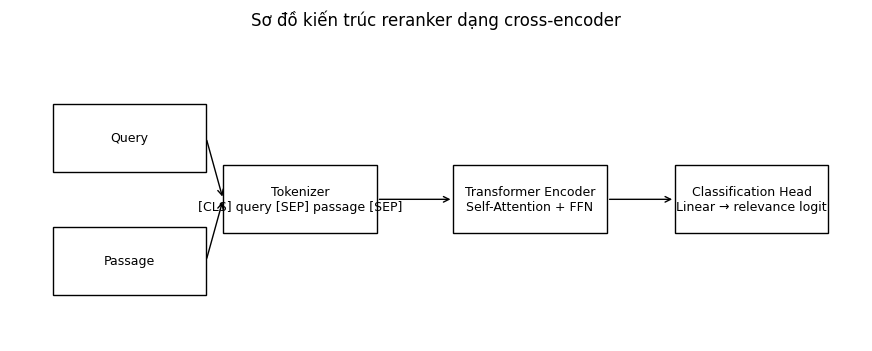

In [13]:
def draw_architecture_diagram():
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.axis("off")

    boxes = [
        (0.05, 0.55, "Query"),
        (0.05, 0.15, "Passage"),
        (0.25, 0.35, "Tokenizer\n[CLS] query [SEP] passage [SEP]"),
        (0.52, 0.35, "Transformer Encoder\nSelf-Attention + FFN"),
        (0.78, 0.35, "Classification Head\nLinear → relevance logit"),
    ]

    for x, y, text in boxes:
        rect = plt.Rectangle((x, y), 0.18, 0.22, fill=False)
        ax.add_patch(rect)
        ax.text(x + 0.09, y + 0.11, text, ha="center", va="center", fontsize=9)

    arrows = [
        ((0.23, 0.66), (0.25, 0.46)),
        ((0.23, 0.26), (0.25, 0.46)),
        ((0.43, 0.46), (0.52, 0.46)),
        ((0.70, 0.46), (0.78, 0.46)),
    ]

    for start, end in arrows:
        ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="->"))

    ax.set_title("Sơ đồ kiến trúc reranker dạng cross-encoder")
    plt.show()

draw_architecture_diagram()


*Hình 1. Sơ đồ kiến trúc tổng quát của reranker cross-encoder. Mô hình nhận đồng thời query và passage, sau đó sinh một relevance logit dùng để xếp hạng.*


## 7. Cấu hình huấn luyện và siêu tham số

Mô hình được fine-tune bằng groupwise cross-entropy. Cấu hình chính của lần chạy:

- `MAX_LENGTH = 512`.
- `TRAIN_NEGATIVES_PER_QUERY = 3`.
- `EVAL_NEGATIVES_PER_QUERY = 31`.
- `PER_DEVICE_TRAIN_BATCH_SIZE = 2` query-groups.
- `GRADIENT_ACCUMULATION_STEPS = 8`.
- `EPOCHS = 2`, nhưng training dừng ở checkpoint tốt nhất quanh step `2065` do early stopping/load best model.
- `LEARNING_RATE = 2e-5`, `WARMUP_RATIO = 0.1`, `WEIGHT_DECAY = 0.01`.
- `EARLY_STOPPING_PATIENCE = 2`, theo dõi `eval_mrr`.

Trainer log train loss và validation metrics theo step, không chỉ cuối epoch, nên learning curve có nhiều mốc để phân tích.


In [14]:
hyperparam_table = pd.DataFrame([
    {"Siêu tham số": "MODEL_NAME", "Giá trị": MODEL_NAME},
    {"Siêu tham số": "MAX_LENGTH", "Giá trị": MAX_LENGTH},
    {"Siêu tham số": "TRAIN_NEGATIVES_PER_QUERY", "Giá trị": TRAIN_NEGATIVES_PER_QUERY},
    {"Siêu tham số": "VAL_NEGATIVES_PER_QUERY", "Giá trị": VAL_NEGATIVES_PER_QUERY},
    {"Siêu tham số": "EVAL_NEGATIVES_PER_QUERY", "Giá trị": EVAL_NEGATIVES_PER_QUERY},
    {"Siêu tham số": "NEGATIVE_STRATEGY", "Giá trị": NEGATIVE_STRATEGY},
    {"Siêu tham số": "TFIDF_TOP_K_POOL", "Giá trị": TFIDF_TOP_K_POOL},
    {"Siêu tham số": "EVAL_TFIDF_TOP_K_POOL", "Giá trị": EVAL_TFIDF_TOP_K_POOL},
    {"Siêu tham số": "PER_DEVICE_TRAIN_BATCH_SIZE", "Giá trị": PER_DEVICE_TRAIN_BATCH_SIZE},
    {"Siêu tham số": "GRADIENT_ACCUMULATION_STEPS", "Giá trị": GRADIENT_ACCUMULATION_STEPS},
    {"Siêu tham số": "EPOCHS", "Giá trị": EPOCHS},
    {"Siêu tham số": "LEARNING_RATE", "Giá trị": LEARNING_RATE},
    {"Siêu tham số": "WARMUP_RATIO", "Giá trị": WARMUP_RATIO},
    {"Siêu tham số": "WEIGHT_DECAY", "Giá trị": WEIGHT_DECAY},
    {"Siêu tham số": "LOG_EVALS_PER_EPOCH", "Giá trị": LOG_EVALS_PER_EPOCH},
    {"Siêu tham số": "EARLY_STOPPING_PATIENCE", "Giá trị": EARLY_STOPPING_PATIENCE},
    {"Siêu tham số": "EARLY_STOPPING_THRESHOLD", "Giá trị": EARLY_STOPPING_THRESHOLD},
])

print("Bảng 7. Cấu hình huấn luyện và siêu tham số")
display(hyperparam_table)


Bảng 7. Cấu hình huấn luyện và siêu tham số


,Siêu tham số,Giá trị
0,MODEL_NAME,namdp-ptit/ViRanker
1,MAX_LENGTH,512
2,TRAIN_NEGATIVES_PER_QUERY,3
3,VAL_NEGATIVES_PER_QUERY,3
4,EVAL_NEGATIVES_PER_QUERY,31
5,NEGATIVE_STRATEGY,tfidf
6,TFIDF_TOP_K_POOL,50
7,EVAL_TFIDF_TOP_K_POOL,100
8,PER_DEVICE_TRAIN_BATCH_SIZE,2
9,GRADIENT_ACCUMULATION_STEPS,8


## 8. Hàm đánh giá ranking và classification view

Các metric ranking chính:

- `MRR@10`: positive càng đứng cao thì càng tốt.
- `NDCG@10`: chất lượng ranking trong top 10.
- `Recall@k`: tỷ lệ query có positive nằm trong top-k.
- `MeanRank`, `MedianRank`: thứ hạng trung bình/trung vị của positive.

Để đáp ứng yêu cầu báo cáo về `Accuracy/Precision/Recall/F1` và `Confusion Matrix`, notebook bổ sung **top-1 classification view**:

- Với mỗi query, passage được model xếp top 1 được xem là dự đoán `relevant`.
- Passage positive thật là nhãn `relevant`.
- Các passage còn lại là `non-relevant`.

Cách nhìn này phù hợp cho reranking, nhưng cần lưu ý `Accuracy` có thể cao do số negative nhiều.


In [15]:
@torch.no_grad()
def score_pairs(
    model,
    tokenizer,
    pairs: List[Tuple[str, str]],
    batch_size: int = 16,
    max_length: int = 1024,
    normalize: bool = False,
) -> List[float]:
    model.eval()
    scores = []

    for start in range(0, len(pairs), batch_size):
        batch_pairs = pairs[start:start + batch_size]
        queries = [x[0] for x in batch_pairs]
        passages = [x[1] for x in batch_pairs]

        encoded = tokenizer(
            queries,
            passages,
            padding=True,
            truncation=True,
            max_length=max_length,
            return_tensors="pt",
        ).to(model.device)

        logits = model(**encoded).logits.view(-1)
        batch_scores = logits.detach().float().cpu().numpy()

        if normalize:
            batch_scores = 1 / (1 + np.exp(-batch_scores))

        scores.extend(batch_scores.tolist())

    return scores


def build_ranking_candidates(
    eval_data: List[Dict[str, str]],
    idx: int,
    num_negatives: int,
    rng: random.Random,
    precomputed_negatives: Optional[List[List[str]]] = None,
) -> Tuple[str, List[str], int]:
    item = eval_data[idx]
    query = item["query"]
    positive = item["pos"]

    negatives = []

    # Ưu tiên hard negatives đã tạo trước bằng TF-IDF.
    if precomputed_negatives is not None:
        for candidate in precomputed_negatives[idx]:
            if candidate != positive and candidate not in negatives:
                negatives.append(candidate)
            if len(negatives) == num_negatives:
                break

    # Fallback random nếu hard negatives chưa đủ.
    attempts = 0
    while len(negatives) < num_negatives and attempts < 1000:
        j = rng.randrange(len(eval_data))
        candidate = eval_data[j]["pos"]
        if j != idx and candidate != positive and candidate not in negatives:
            negatives.append(candidate)
        attempts += 1

    # Fallback tuyến tính nếu eval_data nhỏ.
    if len(negatives) < num_negatives:
        for j, other in enumerate(eval_data):
            candidate = other["pos"]
            if j != idx and candidate != positive and candidate not in negatives:
                negatives.append(candidate)
                if len(negatives) == num_negatives:
                    break

    candidates = [positive] + negatives
    order = list(range(len(candidates)))
    rng.shuffle(order)

    shuffled_candidates = [candidates[i] for i in order]
    positive_new_idx = order.index(0)
    return query, shuffled_candidates, positive_new_idx


def compute_ranking_metrics(ranks: List[int], candidates_per_query: int) -> Dict[str, float]:
    ranks = np.array(ranks)
    metrics = {
        "MRR@10": float(np.mean([1.0 / r if r <= 10 else 0.0 for r in ranks])),
        "NDCG@10": float(np.mean([1.0 / math.log2(r + 1) if r <= 10 else 0.0 for r in ranks])),
        "Recall@1": float(np.mean(ranks <= 1)),
        "Recall@3": float(np.mean(ranks <= 3)),
        "Recall@5": float(np.mean(ranks <= 5)),
        "Recall@10": float(np.mean(ranks <= 10)),
        "MeanRank": float(np.mean(ranks)),
        "MedianRank": float(np.median(ranks)),
        "NumQueries": int(len(ranks)),
        "CandidatesPerQuery": int(candidates_per_query),
    }
    return metrics


def top1_classification_metrics_from_ranks(
    ranks: List[int],
    candidates_per_query: int,
) -> Tuple[Dict[str, float], np.ndarray]:
    ranks = np.array(ranks)
    n = len(ranks)
    tp = int(np.sum(ranks == 1))
    fn = int(n - tp)
    fp = int(n - tp)
    tn = int(n * (candidates_per_query - 1) - fp)

    accuracy = (tp + tn) / max(tp + tn + fp + fn, 1)
    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    metrics = {
        "Top1_Accuracy": float(accuracy),
        "Top1_Precision": float(precision),
        "Top1_Recall": float(recall),
        "Top1_F1": float(f1),
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn,
    }
    cm = np.array([[tn, fp], [fn, tp]])
    return metrics, cm


def evaluate_reranker(
    model,
    tokenizer,
    eval_data: List[Dict[str, str]],
    num_negatives: int = 31,
    batch_size: int = 16,
    max_length: int = 1024,
    seed: int = 42,
    return_details: bool = False,
    precomputed_negatives: Optional[List[List[str]]] = None,
):
    rng = random.Random(seed)
    ranks = []
    details = []

    if precomputed_negatives is not None:
        assert len(precomputed_negatives) == len(eval_data), "precomputed_negatives phải cùng độ dài với eval_data."

    for idx in tqdm(range(len(eval_data)), desc="Evaluating reranker"):
        query, candidates, positive_idx = build_ranking_candidates(
            eval_data,
            idx,
            num_negatives,
            rng,
            precomputed_negatives=precomputed_negatives,
        )
        pairs = [(query, passage) for passage in candidates]
        scores = score_pairs(
            model,
            tokenizer,
            pairs,
            batch_size=batch_size,
            max_length=max_length,
            normalize=False,
        )

        sorted_idx = np.argsort(-np.array(scores))
        rank = int(np.where(sorted_idx == positive_idx)[0][0]) + 1
        ranks.append(rank)

        if return_details:
            top_idx = int(sorted_idx[0])
            details.append({
                "query": query,
                "positive_passage": candidates[positive_idx],
                "predicted_top_passage": candidates[top_idx],
                "positive_rank": rank,
                "positive_score": float(scores[positive_idx]),
                "top_score": float(scores[top_idx]),
                "score_gap_top_minus_positive": float(scores[top_idx] - scores[positive_idx]),
                "candidates_per_query": len(candidates),
                "negative_sampling": "tfidf_hard" if precomputed_negatives is not None else "random",
            })

    metrics = compute_ranking_metrics(ranks, candidates_per_query=1 + num_negatives)
    cls_metrics, cm = top1_classification_metrics_from_ranks(ranks, candidates_per_query=1 + num_negatives)
    metrics.update(cls_metrics)
    metrics["NegativeSampling"] = "tfidf_hard" if precomputed_negatives is not None else "random"

    if return_details:
        return metrics, ranks, cm, pd.DataFrame(details)
    return metrics


def print_metrics(metrics: Dict[str, float]):
    for key, value in metrics.items():
        if isinstance(value, float):
            print(f"{key}: {value:.4f}")
        else:
            print(f"{key}: {value}")


## 9. Đánh giá baseline trước fine-tune

Baseline là `namdp-ptit/ViRanker` ở trạng thái pretrained, chưa fine-tune trên dữ liệu pháp luật của notebook. Baseline được đánh giá trên cùng test set `5,668` query và cùng TF-IDF hard negatives như model sau fine-tune.

Kết quả baseline:

- `MRR@10 = 0.9406`.
- `NDCG@10 = 0.9513`.
- `Recall@1 = 0.9121`.
- `Recall@10 = 0.9838`.
- `Top1_F1 = 0.9121`.
- `MeanRank = 1.4644`.

Baseline đã khá mạnh, nên phần quan trọng là fine-tuning có cải thiện thêm trên cùng điều kiện đánh giá hay không.


In [16]:
# Đánh giá baseline: model hiện tại vẫn là pretrained vì chưa gọi trainer.train().
# Dùng cùng eval_test_data và cùng test_ranking_negatives để so sánh công bằng với mô hình sau fine-tune.

if RUN_BASELINE_EVAL:
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("=" * 60)
    print("ĐÁNH GIÁ BASELINE PRETRAINED TRÊN TEST SET")
    print("=" * 60)
    print("Baseline:", MODEL_NAME, "chưa fine-tune")
    print("Test negative sampling: TF-IDF hard negatives")

    baseline_metrics, baseline_ranks, baseline_cm, baseline_details = evaluate_reranker(
        model,
        tokenizer,
        eval_data=eval_test_data,
        num_negatives=EVAL_NEGATIVES_PER_QUERY,
        batch_size=PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY),
        max_length=MAX_LENGTH,
        seed=SEED,
        return_details=True,
        precomputed_negatives=test_ranking_negatives,
    )

    print_metrics(baseline_metrics)

    os.makedirs("./eval_reranker_baseline", exist_ok=True)
    with open("./eval_reranker_baseline/metrics.json", "w", encoding="utf-8") as f:
        json.dump(baseline_metrics, f, ensure_ascii=False, indent=2)

    baseline_details.to_csv("./eval_reranker_baseline/error_details.csv", index=False, encoding="utf-8-sig")
else:
    print("Bỏ qua baseline evaluation vì RUN_BASELINE_EVAL = False.")
    baseline_metrics, baseline_ranks, baseline_cm, baseline_details = {}, [], None, pd.DataFrame()


ĐÁNH GIÁ BASELINE PRETRAINED TRÊN TEST SET
Baseline: namdp-ptit/ViRanker chưa fine-tune
Test negative sampling: TF-IDF hard negatives


Evaluating reranker:   0%|          | 0/5668 [00:00<?, ?it/s]

MRR@10: 0.9406
NDCG@10: 0.9513
Recall@1: 0.9121
Recall@3: 0.9665
Recall@5: 0.9746
Recall@10: 0.9838
MeanRank: 1.4644
MedianRank: 1.0000
NumQueries: 5668
CandidatesPerQuery: 32
Top1_Accuracy: 0.9945
Top1_Precision: 0.9121
Top1_Recall: 0.9121
Top1_F1: 0.9121
TP: 5170
FP: 498
FN: 498
TN: 175210
NegativeSampling: tfidf_hard


## 10. Fine-tuning

Trainer đánh giá validation nhiều lần trong quá trình train theo `SYNC_EVAL_STEPS`, không phải chỉ sau mỗi epoch. Điều này giúp theo dõi learning curve chi tiết hơn.

Trong output hiện tại, train loss giảm từ `1.4176` xuống `0.3866`, cho thấy model học được tín hiệu phân biệt positive/negative. Validation `eval_mrr` tăng từ `0.9911` lên `0.9940`, trong khi `eval_loss` giảm ở giai đoạn đầu rồi tăng lại về cuối; đây là dấu hiệu cần nhắc đến khi thảo luận overfitting nhẹ.


In [17]:
# Số update steps mỗi epoch của Trainer có tính gradient accumulation.
updates_per_epoch = max(
    1,
    math.ceil(len(train_dataset) / (PER_DEVICE_TRAIN_BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS))
)
SYNC_EVAL_STEPS = max(1, updates_per_epoch // LOG_EVALS_PER_EPOCH)

print("Updates/epoch:", updates_per_epoch)
print("Log/Eval/Save mỗi", SYNC_EVAL_STEPS, "optimizer steps")
print("Ước tính số điểm validation:", math.ceil(EPOCHS * updates_per_epoch / SYNC_EVAL_STEPS))

training_args_kwargs = dict(
    output_dir=OUTPUT_PATH,
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    gradient_accumulation_steps=GRADIENT_ACCUMULATION_STEPS,
    learning_rate=LEARNING_RATE,
    warmup_ratio=WARMUP_RATIO,
    weight_decay=WEIGHT_DECAY,
    fp16=torch.cuda.is_available(),

    # Log train và validation đồng bộ theo cùng một step.
    logging_strategy="steps",
    logging_steps=SYNC_EVAL_STEPS,
    save_strategy="steps",
    save_steps=SYNC_EVAL_STEPS,
    save_total_limit=2,

    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=2,
    load_best_model_at_end=True,

    # Early stopping sẽ theo dõi eval_mrr trên validation hard negatives.
    metric_for_best_model="eval_mrr",
    greater_is_better=True,
    seed=SEED,
)

# Tương thích nhiều phiên bản transformers: evaluation_strategy cũ và eval_strategy mới.
ta_params = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in ta_params:
    training_args_kwargs["eval_strategy"] = "steps"
else:
    training_args_kwargs["evaluation_strategy"] = "steps"

# Một số version yêu cầu eval_steps truyền riêng.
training_args_kwargs["eval_steps"] = SYNC_EVAL_STEPS

training_args = TrainingArguments(**training_args_kwargs)

trainer = GroupwiseRerankerTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_group_dataset,
    data_collator=RerankerGroupCollator(tokenizer=tokenizer, max_length=MAX_LENGTH),
    compute_metrics=compute_group_metrics,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            early_stopping_threshold=EARLY_STOPPING_THRESHOLD,
        )
    ],
)

print("=" * 60)
print("BẮT ĐẦU FINE-TUNING RERANKER")
print("=" * 60)
print(f"Early stopping: patience={EARLY_STOPPING_PATIENCE}, threshold={EARLY_STOPPING_THRESHOLD}")
print("Validation negatives:", "TF-IDF hard negatives")

trainer.train()

trainer.save_model(OUTPUT_PATH)
tokenizer.save_pretrained(OUTPUT_PATH)

print(f"\n✅ Hoàn tất fine-tune. Model đã lưu tại: {OUTPUT_PATH}")


[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Updates/epoch: 1653
Log/Eval/Save mỗi 413 optimizer steps
Ước tính số điểm validation: 9
BẮT ĐẦU FINE-TUNING RERANKER
Early stopping: patience=2, threshold=0.0005
Validation negatives: TF-IDF hard negatives


Step,Training Loss,Validation Loss,Top1 Accuracy,Mrr
413,1.417587,0.059821,0.983060,0.991118
826,0.992426,0.050991,0.984648,0.992059
1239,0.892514,0.044691,0.987648,0.993544
1652,0.738974,0.061335,0.985354,0.992309
2065,0.386616,0.068507,0.988707,0.994015


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Hoàn tất fine-tune. Model đã lưu tại: /content/vietlaw-viranker-finetuned


### 10.1. Learning curves: Loss và metric trên Train/Validation

Các biểu đồ dưới đây phục vụ phần **Kết quả thực nghiệm** của báo cáo.

Từ log đã đồng bộ:

- Train loss giảm đều qua các mốc: `1.4176 -> 0.9924 -> 0.8925 -> 0.7390 -> 0.3866`.
- Validation loss tốt nhất ở step `1239` (`0.0447`), sau đó tăng lên `0.0685` tại step `2065`.
- Validation top-1 accuracy tăng tổng thể từ `0.9831` lên `0.9887`.
- Validation MRR tăng từ `0.9911` lên `0.9940`.

Diễn giải: model học được tín hiệu ranking rõ ràng, nhưng validation loss tăng ở cuối cho thấy cần theo dõi overfitting. Vì ranking metrics vẫn tăng, checkpoint cuối/best vẫn có chất lượng reranking tốt.


Bảng 8a. Log huấn luyện gốc từ Trainer


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_top1_accuracy,eval_mrr,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.417587,157.361847,0.000019,0.249868,413,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,0.249868,413,0.059821,0.983060,0.991118,267.0404,21.222,2.655,NaN,NaN,NaN,NaN,NaN
2,0.992426,4.545695,0.000017,0.499735,826,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,0.499735,826,0.050991,0.984648,0.992059,266.8118,21.240,2.657,NaN,NaN,NaN,NaN,NaN
4,0.892514,248.842194,0.000014,0.749603,1239,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,0.749603,1239,0.044691,0.987648,0.993544,266.5172,21.263,2.660,NaN,NaN,NaN,NaN,NaN
6,0.738974,0.010195,0.000011,0.999471,1652,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,0.999471,1652,0.061335,0.985354,0.992309,266.6548,21.252,2.659,NaN,NaN,NaN,NaN,NaN
8,0.386616,1.304433,0.000008,1.249263,2065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,NaN,NaN,NaN,1.249263,2065,0.068507,0.988707,0.994015,266.8989,21.233,2.656,NaN,NaN,NaN,NaN,NaN


Bảng 8b. Log train/validation đã đồng bộ theo step


,step,epoch,train_loss,eval_loss,eval_top1_accuracy,eval_mrr,learning_rate,eval_runtime,eval_samples_per_second,eval_steps_per_second
0,413,0.249868,1.417587,0.059821,0.983060,0.991118,0.000019,267.0404,21.222,2.655
1,826,0.499735,0.992426,0.050991,0.984648,0.992059,0.000017,266.8118,21.240,2.657
2,1239,0.749603,0.892514,0.044691,0.987648,0.993544,0.000014,266.5172,21.263,2.660
3,1652,0.999471,0.738974,0.061335,0.985354,0.992309,0.000011,266.6548,21.252,2.659
4,2065,1.249263,0.386616,0.068507,0.988707,0.994015,0.000008,266.8989,21.233,2.656


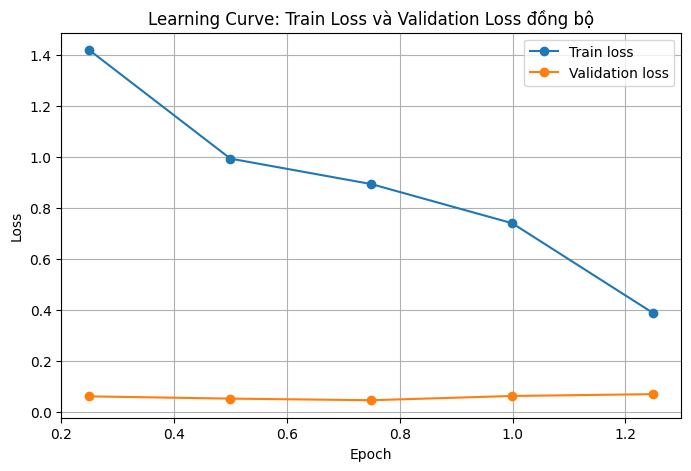

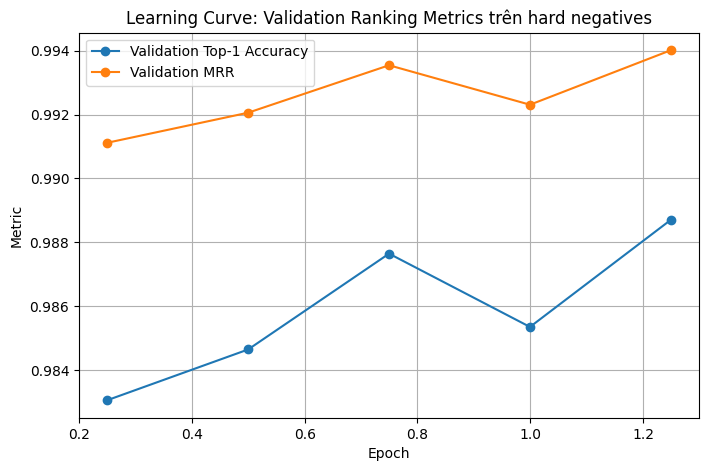

In [18]:
history = pd.DataFrame(trainer.state.log_history)
history.to_csv("./training_log_history_raw.csv", index=False, encoding="utf-8-sig")

print("Bảng 8a. Log huấn luyện gốc từ Trainer")
display(history)

def build_synced_history(history_df: pd.DataFrame) -> pd.DataFrame:
    """Ghép train loss và validation metrics tại cùng mốc step.

    Trainer thường lưu train log và eval log thành hai dòng riêng.
    Hàm này lấy mỗi dòng validation làm mốc, sau đó ghép train loss gần nhất trước hoặc tại cùng step.
    """
    if history_df.empty or "step" not in history_df.columns:
        return pd.DataFrame()

    train_logs = history_df.dropna(subset=["loss"]).copy() if "loss" in history_df.columns else pd.DataFrame()
    eval_logs = history_df.dropna(subset=["eval_loss"]).copy() if "eval_loss" in history_df.columns else pd.DataFrame()

    if eval_logs.empty:
        return pd.DataFrame()

    eval_cols = [
        c for c in [
            "step", "epoch", "eval_loss", "eval_top1_accuracy", "eval_mrr",
            "eval_runtime", "eval_samples_per_second", "eval_steps_per_second"
        ]
        if c in eval_logs.columns
    ]
    eval_logs = eval_logs[eval_cols].sort_values("step")

    if train_logs.empty:
        synced = eval_logs.copy()
        synced["train_loss"] = np.nan
        return synced

    train_cols = [c for c in ["step", "epoch", "loss", "learning_rate"] if c in train_logs.columns]
    train_logs = train_logs[train_cols].sort_values("step")

    synced = pd.merge_asof(
        eval_logs,
        train_logs,
        on="step",
        direction="backward",
        suffixes=("_eval", "_train"),
    )

    if "epoch_eval" in synced.columns:
        synced["epoch"] = synced["epoch_eval"]
    elif "epoch" not in synced.columns and "epoch_train" in synced.columns:
        synced["epoch"] = synced["epoch_train"]

    if "loss" in synced.columns:
        synced = synced.rename(columns={"loss": "train_loss"})

    keep_cols = [
        c for c in [
            "step", "epoch", "train_loss", "eval_loss", "eval_top1_accuracy",
            "eval_mrr", "learning_rate", "eval_runtime",
            "eval_samples_per_second", "eval_steps_per_second"
        ]
        if c in synced.columns
    ]
    return synced[keep_cols]


synced_history = build_synced_history(history)
synced_history.to_csv("./training_log_history_synced.csv", index=False, encoding="utf-8-sig")

print("Bảng 8b. Log train/validation đã đồng bộ theo step")
display(synced_history)

# Learning curve đồng bộ: train loss và validation loss tại cùng mốc step/eval.
plt.figure(figsize=(8, 5))

if not synced_history.empty:
    x = synced_history["epoch"] if "epoch" in synced_history.columns else synced_history["step"]

    if "train_loss" in synced_history.columns:
        plt.plot(x, synced_history["train_loss"], marker="o", label="Train loss")

    if "eval_loss" in synced_history.columns:
        plt.plot(x, synced_history["eval_loss"], marker="o", label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Curve: Train Loss và Validation Loss đồng bộ")
plt.legend()
plt.grid(True)
plt.show()

# Metric curve: validation top-1 accuracy và MRR theo cùng mốc step/eval.
plt.figure(figsize=(8, 5))

if not synced_history.empty:
    x = synced_history["epoch"] if "epoch" in synced_history.columns else synced_history["step"]

    if "eval_top1_accuracy" in synced_history.columns:
        plt.plot(x, synced_history["eval_top1_accuracy"], marker="o", label="Validation Top-1 Accuracy")

    if "eval_mrr" in synced_history.columns:
        plt.plot(x, synced_history["eval_mrr"], marker="o", label="Validation MRR")

plt.xlabel("Epoch")
plt.ylabel("Metric")
plt.title("Learning Curve: Validation Ranking Metrics trên hard negatives")
plt.legend()
plt.grid(True)
plt.show()


### 10.2. Đánh giá trên tập Validation sau fine-tune

Sau fine-tune, validation đạt:

- `MRR@10 = 0.9835`.
- `NDCG@10 = 0.9875`.
- `Recall@1 = 0.9723`.
- `Recall@10 = 0.9993`.
- `Top1_F1 = 0.9723`.
- `MeanRank = 1.0582`.

Kết quả này cho thấy positive passage hầu như luôn nằm rất gần top đầu trên validation set với `32` candidates/query.


In [19]:
val_metrics, val_ranks, val_cm, val_details = evaluate_reranker(
    model,
    tokenizer,
    eval_data=eval_val_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    batch_size=PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY),
    max_length=MAX_LENGTH,
    seed=SEED,
    return_details=True,
    precomputed_negatives=val_ranking_negatives,
)

print("Validation ranking metrics:")
print_metrics(val_metrics)

Evaluating reranker:   0%|          | 0/5667 [00:00<?, ?it/s]

Validation ranking metrics:
MRR@10: 0.9835
NDCG@10: 0.9875
Recall@1: 0.9723
Recall@3: 0.9940
Recall@5: 0.9970
Recall@10: 0.9993
MeanRank: 1.0582
MedianRank: 1.0000
NumQueries: 5667
CandidatesPerQuery: 32
Top1_Accuracy: 0.9983
Top1_Precision: 0.9723
Top1_Recall: 0.9723
Top1_F1: 0.9723
TP: 5510
FP: 157
FN: 157
TN: 175520
NegativeSampling: tfidf_hard


*Hình 2. Learning curve của train loss và validation loss. Train loss giảm mạnh, trong khi validation loss giảm đến step `1239` rồi tăng lại ở các mốc sau; đây là tín hiệu cần kiểm tra overfitting nhẹ.*

*Hình 3. Learning curve của validation top-1 accuracy và MRR. Dù validation loss tăng cuối quá trình, hai metric ranking vẫn tăng tổng thể, với `eval_top1_accuracy` đạt `0.9887` và `eval_mrr` đạt `0.9940` ở mốc cuối được log.*


## 11. Đánh giá trên tập Test sau fine-tune

Test set gồm `5,668` query. Với mỗi query, mô hình xếp hạng `32` candidates gồm `1 positive + 31 TF-IDF hard negatives`.

Kết quả sau fine-tune trên test:

- `MRR@10 = 0.9798`.
- `NDCG@10 = 0.9842`.
- `Recall@1 = 0.9682`.
- `Recall@10 = 0.9972`.
- `Top1_F1 = 0.9682`.
- `MeanRank = 1.1131`.

Nói cách khác, khoảng `96.82%` query có positive passage được xếp top 1.


In [20]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("=" * 60)
print("ĐÁNH GIÁ MODEL SAU FINE-TUNE TRÊN TEST SET")
print("=" * 60)
print("Test negative sampling: TF-IDF hard negatives")

finetuned_metrics, finetuned_ranks, finetuned_cm, finetuned_details = evaluate_reranker(
    model,
    tokenizer,
    eval_data=eval_test_data,
    num_negatives=EVAL_NEGATIVES_PER_QUERY,
    batch_size=PER_DEVICE_TRAIN_BATCH_SIZE * (1 + TRAIN_NEGATIVES_PER_QUERY),
    max_length=MAX_LENGTH,
    seed=SEED,
    return_details=True,
    precomputed_negatives=test_ranking_negatives,
)

print_metrics(finetuned_metrics)

os.makedirs("./eval_reranker_finetuned", exist_ok=True)
with open("./eval_reranker_finetuned/metrics.json", "w", encoding="utf-8") as f:
    json.dump(finetuned_metrics, f, ensure_ascii=False, indent=2)

finetuned_details.to_csv("./eval_reranker_finetuned/error_details.csv", index=False, encoding="utf-8-sig")


ĐÁNH GIÁ MODEL SAU FINE-TUNE TRÊN TEST SET
Test negative sampling: TF-IDF hard negatives


Evaluating reranker:   0%|          | 0/5668 [00:00<?, ?it/s]

MRR@10: 0.9798
NDCG@10: 0.9842
Recall@1: 0.9682
Recall@3: 0.9901
Recall@5: 0.9933
Recall@10: 0.9972
MeanRank: 1.1131
MedianRank: 1.0000
NumQueries: 5668
CandidatesPerQuery: 32
Top1_Accuracy: 0.9980
Top1_Precision: 0.9682
Top1_Recall: 0.9682
Top1_F1: 0.9682
TP: 5488
FP: 180
FN: 180
TN: 175528
NegativeSampling: tfidf_hard


### 11.1. Bảng metric định lượng trên Test và so sánh với baseline

Bảng 9 so sánh hai trạng thái của cùng một mô hình `namdp-ptit/ViRanker`: pretrained baseline và fine-tuned. Cả hai được đánh giá trên cùng `5,668` query test và cùng `31` hard negatives/query.

Fine-tuning cải thiện toàn bộ metric chính:

- `MRR@10`: `0.9406 -> 0.9798` (`+0.0393`).
- `NDCG@10`: `0.9513 -> 0.9842` (`+0.0329`).
- `Recall@1`: `0.9121 -> 0.9682` (`+0.0561`).
- `Recall@10`: `0.9838 -> 0.9972` (`+0.0134`).
- `Top1_F1`: `0.9121 -> 0.9682` (`+0.0561`).
- `MeanRank`: `1.4644 -> 1.1131`, tức positive passage được đẩy gần top 1 hơn.

MedianRank của cả hai đều là `1.0`, nghĩa là ở hơn một nửa số query, positive passage đã nằm top 1 ngay cả trước fine-tune; phần cải thiện chủ yếu nằm ở các query khó còn lại.


In [21]:
# So sánh baseline pretrained và mô hình sau fine-tune trên cùng test set + cùng hard negatives.
result_summary = pd.DataFrame([
    baseline_metrics,
    finetuned_metrics,
], index=[
    "ViRanker baseline pretrained",
    "ViRanker fine-tuned",
])

important_cols = [
    "MRR@10", "NDCG@10", "Recall@1", "Recall@3", "Recall@5", "Recall@10",
    "Top1_Accuracy", "Top1_Precision", "Top1_Recall", "Top1_F1",
    "MeanRank", "MedianRank", "NumQueries", "CandidatesPerQuery",
]
result_summary = result_summary[[c for c in important_cols if c in result_summary.columns]]

print("Bảng 9. So sánh baseline pretrained và ViRanker fine-tuned trên tập Test")
display(result_summary)

# Bảng delta: giá trị dương nghĩa là fine-tuned cải thiện so với baseline.
higher_is_better = [
    "MRR@10", "NDCG@10", "Recall@1", "Recall@3", "Recall@5", "Recall@10",
    "Top1_Accuracy", "Top1_Precision", "Top1_Recall", "Top1_F1",
]
lower_is_better = ["MeanRank", "MedianRank"]

improvement_rows = []
for col in result_summary.columns:
    if col in ["NumQueries", "CandidatesPerQuery"]:
        continue
    base = result_summary.loc["ViRanker baseline pretrained", col]
    ft = result_summary.loc["ViRanker fine-tuned", col]
    if col in higher_is_better:
        delta = ft - base
        direction = "Cao hơn là tốt hơn"
    elif col in lower_is_better:
        delta = base - ft
        direction = "Thấp hơn là tốt hơn"
    else:
        continue
    improvement_rows.append({
        "Metric": col,
        "Baseline": base,
        "Fine-tuned": ft,
        "Cải thiện": delta,
        "Diễn giải": direction,
    })

improvement_summary = pd.DataFrame(improvement_rows)
print("Bảng 9b. Mức cải thiện của fine-tuned so với baseline")
display(improvement_summary)

result_summary.to_csv("./eval_reranker_finetuned/test_metrics_comparison_baseline_vs_finetuned.csv", encoding="utf-8-sig")
improvement_summary.to_csv("./eval_reranker_finetuned/test_metric_improvement.csv", index=False, encoding="utf-8-sig")


Bảng 9. So sánh baseline pretrained và ViRanker fine-tuned trên tập Test


,MRR@10,NDCG@10,Recall@1,Recall@3,Recall@5,Recall@10,Top1_Accuracy,Top1_Precision,Top1_Recall,Top1_F1,MeanRank,MedianRank,NumQueries,CandidatesPerQuery
ViRanker baseline pretrained,0.940551,0.951298,0.912138,0.966478,0.974594,0.983769,0.994509,0.912138,0.912138,0.912138,1.464361,1.0,5668,32
ViRanker fine-tuned,0.979850,0.984165,0.968243,0.990120,0.993296,0.997177,0.998015,0.968243,0.968243,0.968243,1.113091,1.0,5668,32


Bảng 9b. Mức cải thiện của fine-tuned so với baseline


,Metric,Baseline,Fine-tuned,Cải thiện,Diễn giải
0,MRR@10,0.940551,0.979850,0.039299,Cao hơn là tốt hơn
1,NDCG@10,0.951298,0.984165,0.032867,Cao hơn là tốt hơn
2,Recall@1,0.912138,0.968243,0.056104,Cao hơn là tốt hơn
3,Recall@3,0.966478,0.990120,0.023641,Cao hơn là tốt hơn
4,Recall@5,0.974594,0.993296,0.018701,Cao hơn là tốt hơn
5,Recall@10,0.983769,0.997177,0.013409,Cao hơn là tốt hơn
6,Top1_Accuracy,0.994509,0.998015,0.003507,Cao hơn là tốt hơn
7,Top1_Precision,0.912138,0.968243,0.056104,Cao hơn là tốt hơn
8,Top1_Recall,0.912138,0.968243,0.056104,Cao hơn là tốt hơn
9,Top1_F1,0.912138,0.968243,0.056104,Cao hơn là tốt hơn


### 11.2. Confusion Matrix theo top-1 classification view

Confusion matrix được dựng từ góc nhìn top-1: với mỗi query, passage được xếp hạng 1 được xem là dự đoán `relevant`; positive passage thật là nhãn `relevant`, các candidates còn lại là `non-relevant`.

Với test set hiện tại, confusion matrix của model fine-tuned là:

- `TP = 5488`: positive được xếp top 1.
- `FN = 180`: positive không được xếp top 1.
- `FP = 180`: một negative bị xếp top 1 thay positive.
- `TN = 175528`: các negative còn lại không bị chọn làm top 1.

Do mỗi query có nhiều negative, số `TN` rất lớn; vì vậy accuracy `0.9980` nên được diễn giải cẩn thận, và nên ưu tiên các metric ranking như `Recall@1`, `MRR@10`, `NDCG@10`, `Top1_F1`.


Bảng 10. Confusion Matrix của mô hình fine-tuned trên Test


,Pred non-relevant,Pred relevant
True non-relevant,175528,180
True relevant,180,5488


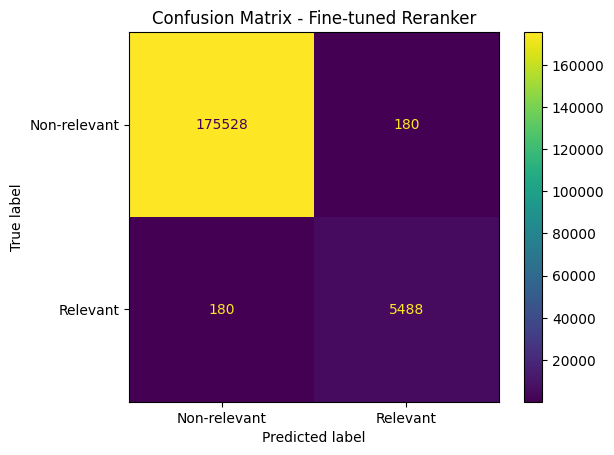

In [22]:
print("Bảng 10. Confusion Matrix của mô hình fine-tuned trên Test")
cm_df = pd.DataFrame(
    finetuned_cm,
    index=["True non-relevant", "True relevant"],
    columns=["Pred non-relevant", "Pred relevant"],
)
display(cm_df)

disp = ConfusionMatrixDisplay(
    confusion_matrix=finetuned_cm,
    display_labels=["Non-relevant", "Relevant"],
)
disp.plot(values_format="d")
plt.title("Confusion Matrix - Fine-tuned Reranker")
plt.show()


*Hình 4. Confusion Matrix của mô hình fine-tuned trên test set theo top-1 classification view. Model xếp đúng positive passage ở top 1 cho `5,488/5,668` query, còn `180` query bị một negative vượt lên top 1. Accuracy cao một phần do số lượng true negative rất lớn (`175,528`), nên khi báo cáo cần nhấn mạnh thêm `Recall@1 = 0.9682`, `MRR@10 = 0.9798` và `Top1_F1 = 0.9682`.*


### 11.3. Biểu đồ so sánh baseline và mô hình fine-tuned

Biểu đồ tập trung vào các metric ranking chính. Khoảng cách lớn nhất nằm ở `Recall@1` và `Top1_F1` (`+0.0561`), cho thấy fine-tuning giúp model chọn đúng passage top 1 tốt hơn, không chỉ cải thiện nhẹ các vị trí trong top 10.


<Figure size 1000x500 with 0 Axes>

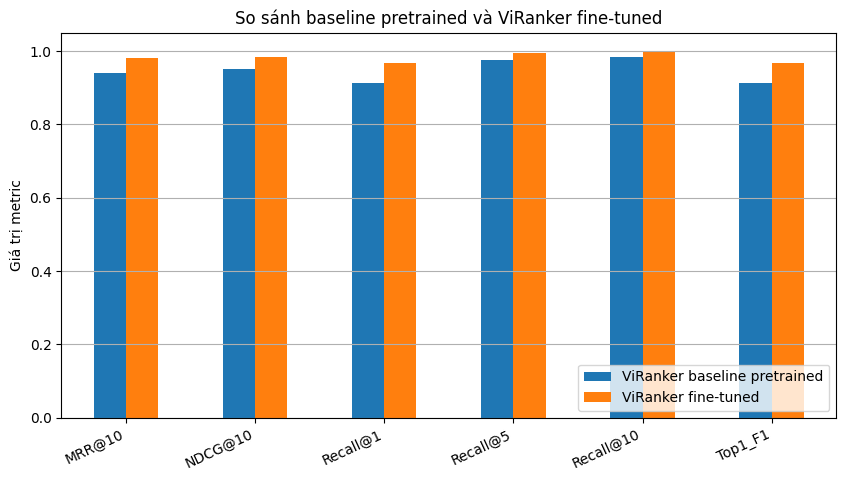

In [23]:
plot_cols = [c for c in ["MRR@10", "NDCG@10", "Recall@1", "Recall@5", "Recall@10", "Top1_F1"] if c in result_summary.columns]

plot_df = result_summary.loc[
    ["ViRanker baseline pretrained", "ViRanker fine-tuned"],
    plot_cols,
].T

plt.figure(figsize=(10, 5))
plot_df.plot(kind="bar", figsize=(10, 5))
plt.ylabel("Giá trị metric")
plt.title("So sánh baseline pretrained và ViRanker fine-tuned")
plt.xticks(rotation=25, ha="right")
plt.ylim(0, 1.05)
plt.grid(axis="y")
plt.legend(loc="lower right")
plt.show()


*Hình 5. Biểu đồ so sánh các metric chính giữa `namdp-ptit/ViRanker` pretrained và `namdp-ptit/ViRanker` fine-tuned trên cùng test set với cùng TF-IDF hard negatives. Fine-tuned model vượt baseline ở tất cả metric được vẽ.*


## 12. Thảo luận: Overfitting/Underfitting và mức độ hội tụ

Nhận xét tự động từ log huấn luyện cho thấy ba điểm chính:

- Train loss giảm mạnh, chứng tỏ model học được tín hiệu từ dữ liệu.
- Validation loss tăng về cuối, nên có dấu hiệu overfitting nhẹ hoặc calibration score chưa ổn định.
- Validation top-1 accuracy và MRR vẫn tăng tổng thể, nên chất lượng ranking vẫn được cải thiện.

Vì mục tiêu chính là reranking, cần ưu tiên phân tích `MRR@10`, `Recall@1`, `NDCG@10` hơn là chỉ nhìn validation loss.


In [24]:
def analyze_training_behavior(history_df: pd.DataFrame):
    comments = []

    train_logs = history_df.dropna(subset=["loss"]) if "loss" in history_df.columns else pd.DataFrame()
    eval_logs = history_df.dropna(subset=["eval_loss"]) if "eval_loss" in history_df.columns else pd.DataFrame()

    if len(train_logs) >= 2:
        first_train = float(train_logs["loss"].iloc[0])
        last_train = float(train_logs["loss"].iloc[-1])
        if last_train < first_train:
            comments.append("Train loss giảm so với ban đầu, cho thấy mô hình có học được tín hiệu từ dữ liệu.")
        else:
            comments.append("Train loss chưa giảm rõ ràng; có thể cần tăng epoch, kiểm tra learning rate hoặc chất lượng dữ liệu.")

    if len(eval_logs) >= 2:
        first_eval = float(eval_logs["eval_loss"].iloc[0])
        last_eval = float(eval_logs["eval_loss"].iloc[-1])
        if last_eval <= first_eval:
            comments.append("Validation loss không tăng so với ban đầu, chưa thấy dấu hiệu overfitting rõ rệt.")
        else:
            comments.append("Validation loss tăng, trong khi train loss có thể giảm; đây là dấu hiệu cần kiểm tra overfitting.")

    if "eval_top1_accuracy" in history_df.columns:
        metric_logs = history_df.dropna(subset=["eval_top1_accuracy"])
        if len(metric_logs) >= 2:
            first_acc = float(metric_logs["eval_top1_accuracy"].iloc[0])
            last_acc = float(metric_logs["eval_top1_accuracy"].iloc[-1])
            if last_acc >= first_acc:
                comments.append("Validation top-1 accuracy tăng hoặc giữ ổn định, cho thấy chất lượng ranking cải thiện.")
            else:
                comments.append("Validation top-1 accuracy giảm; cần kiểm tra overfitting hoặc negative sampling quá nhiễu.")

    if not comments:
        comments.append("Chưa đủ log để kết luận. Cần chạy training ít nhất 2 epoch hoặc tăng logging/evaluation.")

    return comments

print("Nhận xét sơ bộ về quá trình học:")
for c in analyze_training_behavior(history):
    print("-", c)


Nhận xét sơ bộ về quá trình học:
- Train loss giảm so với ban đầu, cho thấy mô hình có học được tín hiệu từ dữ liệu.
- Validation loss tăng, trong khi train loss có thể giảm; đây là dấu hiệu cần kiểm tra overfitting.
- Validation top-1 accuracy tăng hoặc giữ ổn định, cho thấy chất lượng ranking cải thiện.


Một số hướng xử lý nếu muốn giảm rủi ro overfitting ở các lần chạy sau:

- Dừng sớm hơn quanh mốc validation loss thấp nhất, ví dụ gần step `1239`, rồi so sánh lại ranking metrics.
- Giảm số epoch hoặc tăng early stopping nghiêm hơn.
- Tăng/điều chỉnh weight decay.
- Giữ TF-IDF hard negatives nhưng rà soát negative bị nhiễu, vì trong pháp luật có nhiều passage khác nhau nhưng cùng đúng về nghĩa.
- Chunk passage dài để tránh mất thông tin quan trọng do truncation ở `MAX_LENGTH = 512`.
- Luôn giữ test set cố định và chỉ dùng validation để chọn checkpoint.


## 13. Phân tích lỗi

Phần này lấy các trường hợp mà positive passage không được xếp top 1. Trên test set, model fine-tuned còn `180` query sai top-1. Bảng 11 liệt kê một số lỗi nặng, ví dụ positive bị xếp ở rank `30`, `27`, `24` hoặc có score gap rất lớn so với passage bị chọn nhầm.

Các lỗi này hữu ích cho báo cáo vì chúng cho thấy điểm yếu còn lại của reranker, đặc biệt khi negative passage có nhiều thuật ngữ pháp lý trùng với query hoặc khi positive passage quá chung/dài.


In [25]:
def error_table_from_details(details_df: pd.DataFrame, max_rows: int = 20) -> pd.DataFrame:
    if details_df.empty:
        return details_df

    errors = details_df[details_df["positive_rank"] > 1].copy()
    if errors.empty:
        return errors

    errors["query_short"] = errors["query"].str.slice(0, 250)
    errors["positive_short"] = errors["positive_passage"].str.slice(0, 350)
    errors["predicted_top_short"] = errors["predicted_top_passage"].str.slice(0, 350)
    errors["score_gap_top_minus_positive"] = errors["top_score"] - errors["positive_score"]

    cols = [
        "positive_rank",
        "score_gap_top_minus_positive",
        "query_short",
        "positive_short",
        "predicted_top_short",
    ]
    return errors[cols].sort_values(["positive_rank", "score_gap_top_minus_positive"], ascending=[False, False]).head(max_rows)

error_examples = error_table_from_details(finetuned_details, max_rows=20)

print("Bảng 11. Một số trường hợp mô hình fine-tuned xếp sai trên Test")
display(error_examples)

error_examples.to_csv("./eval_reranker_finetuned/error_examples_for_report.csv", index=False, encoding="utf-8-sig")


Bảng 11. Một số trường hợp mô hình fine-tuned xếp sai trên Test


,positive_rank,score_gap_top_minus_positive,query_short,positive_short,predicted_top_short
207,30,10.171875,"Tôi đang quản lý một tài sản của công ty, liệu...",Điều 188. Quyền chiếm hữu của người được giao ...,Điều 241. Xử lý tài sản để thực hiện nghĩa vụ ...
5627,27,7.156250,Người sử dụng lao động phải trả tiền lương làm...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Chương VI của Bộ luật Lao động Việt Nam quy đị...
1903,27,5.687500,Người sử dụng lao động phải đảm bảo thời gian ...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Chương V của Bộ luật Lao động 2019 quy định về...
1552,27,0.500000,Người lao động có quyền nghỉ bao nhiêu ngày kh...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Điều 139. Nghỉ thai sản 1. Lao động nữ được ng...
63,24,22.933594,Người lao động có quyền tham gia bảo hiểm xã h...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Căn cứ theo Điều 18 Luật Bảo hiểm xã hội 2014 ...
1556,23,1.171875,"Người sử dụng lao động phải tổ chức đào tạo, b...",Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Điều 60. Trách nhiệm của người sử dụng lao độn...
2119,23,1.156250,Người sử dụng lao động phải thông báo trước ba...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Điều 177. Nghĩa vụ của người sử dụng lao động ...
4403,21,16.074219,Người sử dụng lao động phải trả tiền lương thử...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Điều 26. Tiền lương thử việc Tiền lương của ng...
1216,20,33.078125,Nếu tôi là thành viên công ty nhưng hiện tại đ...,Điều 53. Xử lý phần vốn góp trong một số trườn...,Điều 156. Chủ tịch Hội đồng quản trị 1. Chủ tị...
192,19,1.281250,Người lao động có quyền nghỉ không hưởng lương...,Bộ Luật Lao Động Việt Nam 2019 quy định các ti...,Điều 139. Nghỉ thai sản 1. Lao động nữ được ng...


Gợi ý phân tích lỗi trong báo cáo:

- **Passage pháp luật gần nghĩa nhau**: negative có thể chứa điều khoản hoặc thuật ngữ rất gần query nên được score cao hơn positive.
- **Positive passage quá tổng quát**: nhiều positive trong nhóm lao động bắt đầu bằng mô tả chung của Bộ luật Lao động, khiến model khó phân biệt với các passage chuyên biệt hơn.
- **Passage dài bị cắt**: thông tin trả lời có thể nằm sau phần bị truncation bởi `MAX_LENGTH = 512`.
- **Nhiễu nhãn hoặc nhiều đáp án đúng**: một negative trong dataset có thể thực ra cũng trả lời được query.
- **Khớp từ vựng mạnh**: TF-IDF hard negatives cố tình chọn các đoạn giống query về mặt từ khóa, nên lỗi còn lại thường là các ca khó.


## 14. Test inference thủ công

Cell dưới đây thử chấm điểm hai passage cho cùng một query. Cả hai raw score đều âm và sigmoid gần `0`, nên không nên diễn giải sigmoid như xác suất tuyệt đối trong ví dụ này. Điều quan trọng là **so sánh tương đối**: passage tốt có raw score `-12.0938`, cao hơn passage không liên quan `-17.0469`, tức model vẫn xếp passage tốt hơn.


In [26]:
sample_query = "Người lao động nghỉ việc có được hưởng trợ cấp thôi việc không?"
sample_passage_good = "Người lao động đã làm việc thường xuyên từ đủ 12 tháng trở lên khi chấm dứt hợp đồng lao động đúng quy định có thể được người sử dụng lao động chi trả trợ cấp thôi việc, trừ các trường hợp pháp luật loại trừ."
sample_passage_bad = "Doanh nghiệp phải kê khai thuế giá trị gia tăng theo tháng hoặc theo quý tùy thuộc điều kiện pháp luật về thuế."

pairs = [
    (sample_query, sample_passage_good),
    (sample_query, sample_passage_bad),
]

raw_scores = score_pairs(model, tokenizer, pairs, batch_size=2, max_length=MAX_LENGTH, normalize=False)
norm_scores = score_pairs(model, tokenizer, pairs, batch_size=2, max_length=MAX_LENGTH, normalize=True)

for pair, raw, norm in zip(pairs, raw_scores, norm_scores):
    print("=" * 80)
    print("Query:", pair[0])
    print("Passage:", pair[1])
    print(f"Raw score: {raw:.4f}")
    print(f"Sigmoid score: {norm:.4f}")


Query: Người lao động nghỉ việc có được hưởng trợ cấp thôi việc không?
Passage: Người lao động đã làm việc thường xuyên từ đủ 12 tháng trở lên khi chấm dứt hợp đồng lao động đúng quy định có thể được người sử dụng lao động chi trả trợ cấp thôi việc, trừ các trường hợp pháp luật loại trừ.
Raw score: -12.0938
Sigmoid score: 0.0000
Query: Người lao động nghỉ việc có được hưởng trợ cấp thôi việc không?
Passage: Doanh nghiệp phải kê khai thuế giá trị gia tăng theo tháng hoặc theo quý tùy thuộc điều kiện pháp luật về thuế.
Raw score: -17.0469
Sigmoid score: 0.0000


## 15. Lưu model, kết quả và nén artifact

Notebook lưu các artifact chính vào `/content`:

- `/content/vietlaw-viranker-finetuned/`: model fine-tuned, tokenizer, config, training args và các checkpoint còn giữ lại.
- `/content/report_artifacts/`: các bảng CSV phục vụ báo cáo.
- `/content/training_log_history_raw.csv` và `/content/training_log_history_synced.csv`: log huấn luyện.
- `/content/vietlaw-viranker-finetuned.zip`: file nén chứa model, report artifacts và training logs, dung lượng output khoảng `9.5G` trong lần chạy hiện tại.

Các folder `eval_reranker_baseline/` và `eval_reranker_finetuned/` được copy riêng lên Drive ở các cell sau, vì không nằm trong file zip ban đầu nhưng chứa metrics/error details chi tiết.


In [27]:
# Luu lai toan bo ket qua can cho bao cao trong local runtime /content.
ARTIFACT_DIR = "/content/report_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)

split_summary.to_csv(f"{ARTIFACT_DIR}/table_2_split_summary.csv", index=False, encoding="utf-8-sig")
source_summary.to_csv(f"{ARTIFACT_DIR}/table_3_source_distribution.csv", index=False, encoding="utf-8-sig")
arch_summary.to_csv(f"{ARTIFACT_DIR}/table_6_architecture.csv", index=False, encoding="utf-8-sig")
hyperparam_table.to_csv(f"{ARTIFACT_DIR}/table_7_hyperparameters.csv", index=False, encoding="utf-8-sig")
history.to_csv(f"{ARTIFACT_DIR}/table_8a_training_log_raw.csv", index=False, encoding="utf-8-sig")
synced_history.to_csv(f"{ARTIFACT_DIR}/table_8b_training_log_synced.csv", index=False, encoding="utf-8-sig")
result_summary.to_csv(f"{ARTIFACT_DIR}/table_9_test_metrics_baseline_vs_finetuned.csv", encoding="utf-8-sig")
improvement_summary.to_csv(f"{ARTIFACT_DIR}/table_9b_metric_improvement.csv", index=False, encoding="utf-8-sig")
cm_df.to_csv(f"{ARTIFACT_DIR}/table_10_confusion_matrix.csv", encoding="utf-8-sig")
error_examples.to_csv(f"{ARTIFACT_DIR}/table_11_error_examples.csv", index=False, encoding="utf-8-sig")
finetuned_details.to_csv(f"{ARTIFACT_DIR}/test_error_details_full.csv", index=False, encoding="utf-8-sig")
baseline_details.to_csv(f"{ARTIFACT_DIR}/baseline_error_details_full.csv", index=False, encoding="utf-8-sig")

print("Da luu artifacts vao", ARTIFACT_DIR)


Da luu artifacts vao /content/report_artifacts


In [28]:
!zip -r /content/vietlaw-viranker-finetuned.zip /content/vietlaw-viranker-finetuned/ /content/report_artifacts/ /content/training_log_history_raw.csv /content/training_log_history_synced.csv
!ls -lh /content/vietlaw-viranker-finetuned.zip


  adding: content/vietlaw-viranker-finetuned/ (stored 0%)
  adding: content/vietlaw-viranker-finetuned/tokenizer.json (deflated 76%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/ (stored 0%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/tokenizer.json (deflated 76%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/scheduler.pt (deflated 61%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/tokenizer_config.json (deflated 49%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/optimizer.pt (deflated 50%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/model.safetensors (deflated 19%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/scaler.pt (deflated 64%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/trainer_state.json (deflated 69%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/rng_state.pth (deflated 26%)
  adding: content/vietlaw-viranker-finetuned/checkpoint-2065/

In [30]:
from google.colab import drive
drive.mount("/content/drive")

import shutil
from pathlib import Path

src = Path("/content/vietlaw-viranker-finetuned.zip")
dst_dir = Path("/content/drive/MyDrive/Project_ML")
dst_dir.mkdir(parents=True, exist_ok=True)

dst = dst_dir / src.name

print("Source exists:", src.exists())
print("Source size GB:", src.stat().st_size / (1024**3) if src.exists() else None)

shutil.copy2(src, dst)

print("Copied to:", dst)
print("Drive size GB:", dst.stat().st_size / (1024**3))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Source exists: True
Source size GB: 9.419312248937786
Copied to: /content/drive/MyDrive/Project_ML/vietlaw-viranker-finetuned.zip
Drive size GB: 9.419312248937786


In [31]:
from pathlib import Path
import os, time

dst = Path("/content/drive/MyDrive/Project_ML/vietlaw-viranker-finetuned.zip")

print("Exists in mounted Drive:", dst.exists())
if dst.exists():
    print("Size GB:", dst.stat().st_size / (1024**3))

os.sync()
time.sleep(10)
print("Đã sync. Chờ 1-3 phút rồi refresh Drive UI.")

Exists in mounted Drive: True
Size GB: 9.419312248937786
Đã sync. Chờ 1-3 phút rồi refresh Drive UI.


In [32]:
from google.colab import drive
drive.mount("/content/drive")

import shutil
from pathlib import Path

src_dirs = [
    Path("/content/eval_reranker_baseline"),
    Path("/content/eval_reranker_finetuned"),
]

dst_base = Path("/content/drive/MyDrive/Project_ML")
dst_base.mkdir(parents=True, exist_ok=True)

for src in src_dirs:
    dst = dst_base / src.name

    print("Copy:", src, "=>", dst)
    print("Source exists:", src.exists())

    if not src.exists():
        continue

    if dst.exists():
        shutil.rmtree(dst)

    shutil.copytree(src, dst)
    print("Done:", dst)

print("Xong.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Copy: /content/eval_reranker_baseline => /content/drive/MyDrive/Project_ML/eval_reranker_baseline
Source exists: True
Done: /content/drive/MyDrive/Project_ML/eval_reranker_baseline
Copy: /content/eval_reranker_finetuned => /content/drive/MyDrive/Project_ML/eval_reranker_finetuned
Source exists: True
Done: /content/drive/MyDrive/Project_ML/eval_reranker_finetuned
Xong.


## 16. Kết luận cho báo cáo

Kết quả thực nghiệm cho thấy fine-tuning giúp `namdp-ptit/ViRanker` thích nghi tốt hơn với miền pháp luật tiếng Việt. Trên test set gồm `5,668` query và `32` candidates/query, model fine-tuned cải thiện rõ so với baseline pretrained của cùng kiến trúc:

- `MRR@10` tăng từ `0.9406` lên `0.9798`.
- `NDCG@10` tăng từ `0.9513` lên `0.9842`.
- `Recall@1` tăng từ `0.9121` lên `0.9682`.
- `Recall@10` tăng từ `0.9838` lên `0.9972`.
- `Top1_F1` tăng từ `0.9121` lên `0.9682`.
- `MeanRank` giảm từ `1.4644` xuống `1.1131`.

Confusion matrix theo top-1 view cho thấy model xếp đúng positive passage ở top 1 cho `5,488/5,668` query. Tuy nhiên, accuracy `0.9980` cao một phần do số lượng true negative lớn, nên báo cáo nên ưu tiên diễn giải `Recall@1`, `MRR@10`, `NDCG@10` và `Top1_F1`.

Learning curves cho thấy train loss giảm mạnh và validation MRR/top-1 accuracy tăng, nhưng validation loss tăng lại ở cuối quá trình. Điều này gợi ý model đã học được tín hiệu ranking tốt nhưng vẫn cần theo dõi overfitting nhẹ hoặc thử chọn checkpoint dựa trên validation loss/ranking metric tùy mục tiêu.

Các lỗi còn lại thường xuất hiện khi passage sai có thuật ngữ pháp lý rất gần query, khi positive passage quá tổng quát hoặc quá dài bị cắt bởi `MAX_LENGTH = 512`, hoặc khi nhiều passage trong tập ứng viên đều có thể liên quan về mặt ngữ nghĩa.

## 17. Tài liệu tham khảo và nguồn

1. Nam Dang Phuong. `namdp-ptit/ViRanker`, Hugging Face model card.  
2. Xiao et al. BGE-M3: Multi-Lingual, Multi-Functionality, Multi-Granularity Text Embeddings.  
3. Vaswani et al. *Attention Is All You Need*.  
4. Hugging Face Transformers Documentation.  
5. Hugging Face Datasets Documentation.
